In [3]:
import numpy as np
import matplotlib.pyplot as plt

[0.6 0.8 1.  1.2 1.4]


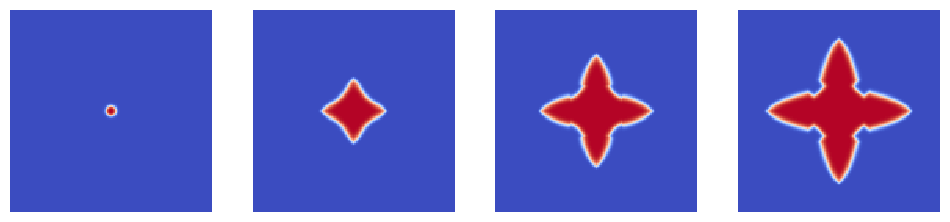

In [4]:
save_dir = "./data"
solutions = np.load(f"{save_dir}/train_valid/solutions_grid.npy")[1, :, 0, ...]
mesh = np.load(f"{save_dir}/train_valid/mesh_grid_coords.npy")
ks = np.load(f"{save_dir}/train_valid/K_values.npy")
print(ks)
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 60, 120, 160]

fig, axes = plt.subplots(1, len(tics), figsize=(12, 3))
axes = axes.flatten()
for i, tic in enumerate(tics):
    ax = axes[i]
    ax.pcolormesh(meshx, meshy, solutions[tic, :, :], cmap='coolwarm')
    ax.set_aspect('equal')
    ax.set_axis_off()

In [5]:
from configs.train_debug import Configs
configs = Configs()
mesh = np.load(f"{save_dir}/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
times = np.load(f"{save_dir}/train_valid/times.npy")
dt = times[1] - times[0]
num_times = times.shape[0]
solutions = np.load(f"{save_dir}/train_valid/solutions_grid.npy")
num_ks = solutions.shape[0]
Xs = np.zeros(
    (num_ks * (num_times - 1), 5, 
     mesh.shape[1], mesh.shape[2])
) # 4: phi, T, meshx, meshy, k
Ys = np.zeros(
    (num_ks * (num_times - 1), 2, 
     mesh.shape[1], mesh.shape[2])
) # 2: phi, T
K_values = np.load(f"{save_dir}/train_valid/K_values.npy")
Ks = np.zeros((num_ks * (num_times - 1), 1))

for i in range(num_ks):
    Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
    Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # T
    Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = meshx / configs.Lc  # meshx
    Xs[i*(num_times-1):(i+1)*(num_times-1), 4, :, :] = meshy / configs.Lc  # meshy
    Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = K_values[i]  # k

    Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi
    Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # T

    Ks[i*(num_times-1):(i+1)*(num_times-1), 0] = K_values[i]

In [4]:
times.shape

(201,)

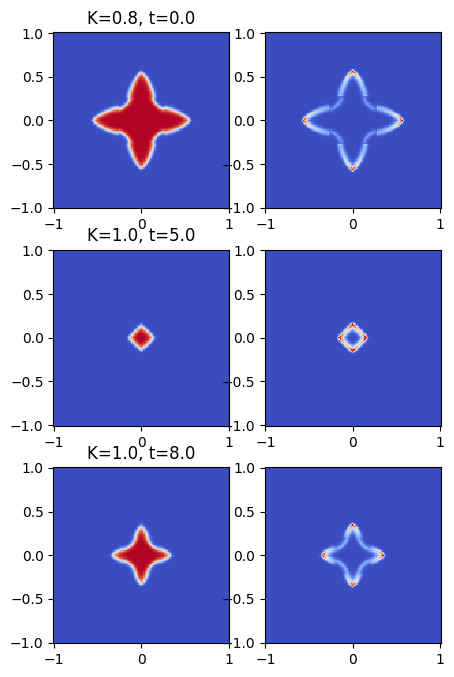

In [5]:
import matplotlib.pyplot as plt
ts = [0, 100, 159]
fig, axes = plt.subplots(3, 2, figsize=(5, 8))
for idx, t in enumerate(ts):
    t += 160*2
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 3, :, :] * configs.Lc
    meshy = Xs[t, 4, :, :] * configs.Lc
    ax = axes[idx, 0]
    im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.set_aspect('equal')
    k = Xs[t, 2, 0, 0]
    ax.set_title(f"K={k:.1f}, t={ts[idx] * dt:.1f}")

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.set_aspect('equal')


In [6]:
# solutions[0, 100, 1, :, :].min(), solutions[0, 100, 1, :, :].max()
np.max(solutions[0, :, 1, :, :], axis=(1,2))

array([ 0.        , -0.0028929 , -0.02917061, -0.06211046, -0.08779008,
       -0.10618892, -0.11931944, -0.12880176, -0.13571918, -0.14078103,
       -0.14447382, -0.1471383 , -0.14881234, -0.1439963 , -0.14078348,
       -0.13703962, -0.13305906, -0.1305599 , -0.12606233, -0.12274472,
       -0.12072608, -0.11687185, -0.11379879, -0.11201309, -0.10843269,
       -0.1054456 , -0.10375882, -0.10152719, -0.09834687, -0.09658137,
       -0.09535092, -0.09180803, -0.08983219, -0.0888166 , -0.08651828,
       -0.08414055, -0.08288182, -0.08195881, -0.07897277, -0.07732014,
       -0.07651544, -0.07500235, -0.07276212, -0.07157707, -0.07105697,
       -0.0688311 , -0.06705993, -0.06616368, -0.06580602, -0.06362291,
       -0.06216281, -0.06145457, -0.06110517, -0.05877843, -0.05748031,
       -0.05685969, -0.05664599, -0.05458074, -0.05337694, -0.05280331,
       -0.05261008, -0.05059647, -0.04937261, -0.04877013, -0.04855115,
       -0.04713169, -0.04585093, -0.04519683, -0.04493865, -0.04

In [7]:
Ks.shape

(1000, 1)

In [8]:
np.savez(
    f"{save_dir}/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

In [9]:
print(mesh[0])
print(mesh[1])

[[-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 ...
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]]
[[-1.       -1.       -1.       ... -1.       -1.       -1.      ]
 [-0.984375 -0.984375 -0.984375 ... -0.984375 -0.984375 -0.984375]
 [-0.96875  -0.96875  -0.96875  ... -0.96875  -0.96875  -0.96875 ]
 ...
 [ 0.96875   0.96875   0.96875  ...  0.96875   0.96875   0.96875 ]
 [ 0.984375  0.984375  0.984375 ...  0.984375  0.984375  0.984375]
 [ 1.        1.        1.       ...  1.        1.        1.      ]]


In [10]:
K_values

array([0.6, 0.8, 1. , 1.2, 1.4])

In [11]:
times

array([ 0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,
        0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,  0.8 ,  0.85,
        0.9 ,  0.95,  1.  ,  1.05,  1.1 ,  1.15,  1.2 ,  1.25,  1.3 ,
        1.35,  1.4 ,  1.45,  1.5 ,  1.55,  1.6 ,  1.65,  1.7 ,  1.75,
        1.8 ,  1.85,  1.9 ,  1.95,  2.  ,  2.05,  2.1 ,  2.15,  2.2 ,
        2.25,  2.3 ,  2.35,  2.4 ,  2.45,  2.5 ,  2.55,  2.6 ,  2.65,
        2.7 ,  2.75,  2.8 ,  2.85,  2.9 ,  2.95,  3.  ,  3.05,  3.1 ,
        3.15,  3.2 ,  3.25,  3.3 ,  3.35,  3.4 ,  3.45,  3.5 ,  3.55,
        3.6 ,  3.65,  3.7 ,  3.75,  3.8 ,  3.85,  3.9 ,  3.95,  4.  ,
        4.05,  4.1 ,  4.15,  4.2 ,  4.25,  4.3 ,  4.35,  4.4 ,  4.45,
        4.5 ,  4.55,  4.6 ,  4.65,  4.7 ,  4.75,  4.8 ,  4.85,  4.9 ,
        4.95,  5.  ,  5.05,  5.1 ,  5.15,  5.2 ,  5.25,  5.3 ,  5.35,
        5.4 ,  5.45,  5.5 ,  5.55,  5.6 ,  5.65,  5.7 ,  5.75,  5.8 ,
        5.85,  5.9 ,  5.95,  6.  ,  6.05,  6.1 ,  6.15,  6.2 ,  6.25,
        6.3 ,  6.35,